# COP9517 lab04 Han Qin z5565186
import all needed package

In [208]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
from sklearn.model_selection import train_test_split
# KNN classifier
from sklearn.neighbors import KNeighborsClassifier
# DT classifier
from sklearn.tree import DecisionTreeClassifier
# SGD classifier
from sklearn.linear_model import SGDClassifier
# comprision display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    )

- Convert the input image to grayscale and apply Otsu intensity thresholding. 

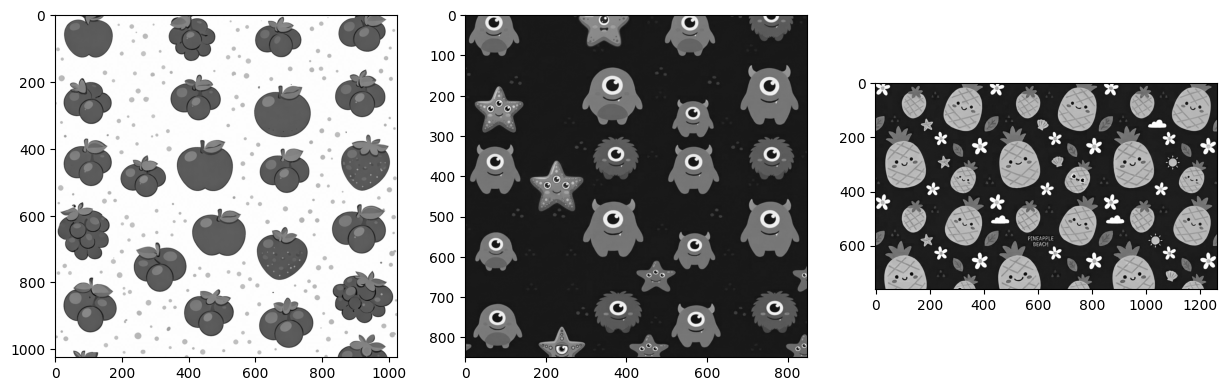

Obtained threshold:  172.0
Obtained threshold:  77.0
Obtained threshold:  102.0


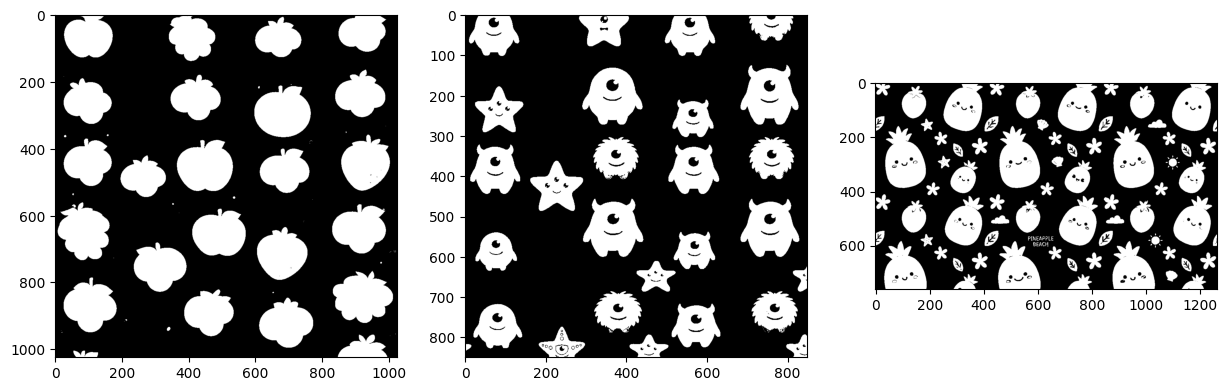

In [209]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
# open it
path = "image"
images_gray = []
images_rgb = []
i = 0
for filename in os.listdir(path):
    if filename.endswith('jpg'):
        img = cv.imread(f'{path}/{filename}')
        img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        axes[i].imshow(img_gray, cmap='gray')
        images_gray.append(img_gray)
        images_rgb.append(img_rgb)
        i = i +1
plt.show()
i = 0
# Thresholding:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

images_thresh = []
for img in images_gray:
    otsu_threshold, image_result = cv.threshold(
        img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU,
    )

    # we notice the first image should do a color flip
    if i == 0:
        image_result = cv.bitwise_not(image_result)
    print("Obtained threshold: ", otsu_threshold)
    images_thresh.append(image_result)
    axes[i].imshow(image_result, cmap='gray')
    i = i + 1
    # bin_num = 256
    # # get the histogram
    # hist, bin_edges = np.histogram(img, bins=bin_num)
    # # get normalized
    # bin_mids = (bin_edges[:-1] + bin_edges[1:]) / 2

    # # Iterate over all thresholds (indices) and get the probabilities w1(t), w2(t)
    # weight1 = np.cumsum(hist)
    # weight2 = np.cumsum(hist[::-1])[::-1]
    # # Get the class means mu0(t)
    # mean1 = np.cumsum(hist * bin_mids) / weight1
    # # Get the class means mu1(t)
    # mean2 = (np.cumsum((hist * bin_mids)[::-1]) / weight2[::-1])[::-1]

    # inter_class_variance = weight1[:-1] * weight2[1:] * (mean1[:-1] - mean2[1:]) ** 2

    # # Maximize the inter_class_variance function val
    # index_of_max_val = np.argmax(inter_class_variance)

    # threshold = bin_mids[:-1][index_of_max_val]
    # print("Otsu's algorithm implementation thresholding result: ", threshold)


plt.show()


- Next, use opening and closing operators to filter out noise and fill holes in the segmentation, 


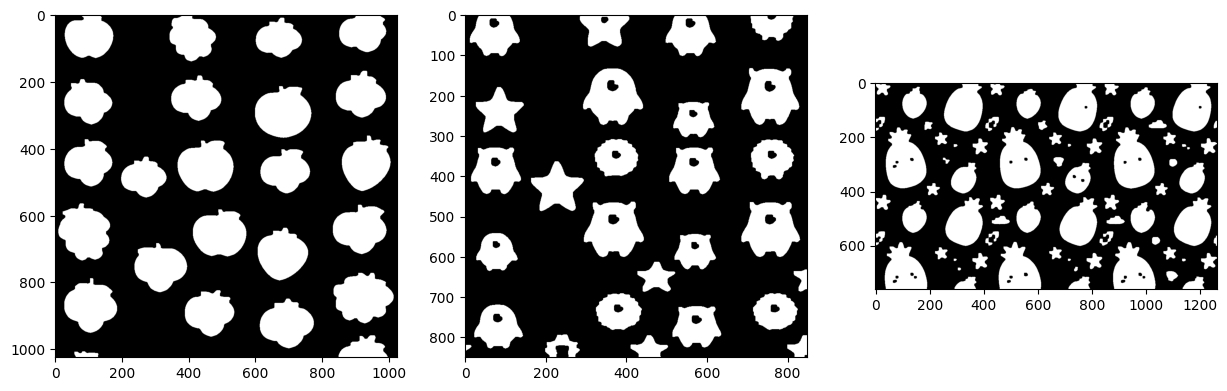

In [210]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
kernel_close = cv.getStructuringElement(cv.MORPH_ELLIPSE, (10, 10))
kernel_open = cv.getStructuringElement(cv.MORPH_ELLIPSE, (10, 10))
images_os = []
i = 0
for img in images_thresh:
   # wipe white
   image_opening = cv.morphologyEx(img, cv.MORPH_OPEN, kernel_open)
   image_closing = cv.morphologyEx(image_opening, cv.MORPH_CLOSE, kernel_close)
   axes[i].imshow(image_closing, cmap='gray')
   images_os.append(image_closing)
   i = i + 1
plt.show()


- identify connected components and use reconstruction operations to get rid of segmented objects touching the image boundary,remove objects that are smaller than a certain size

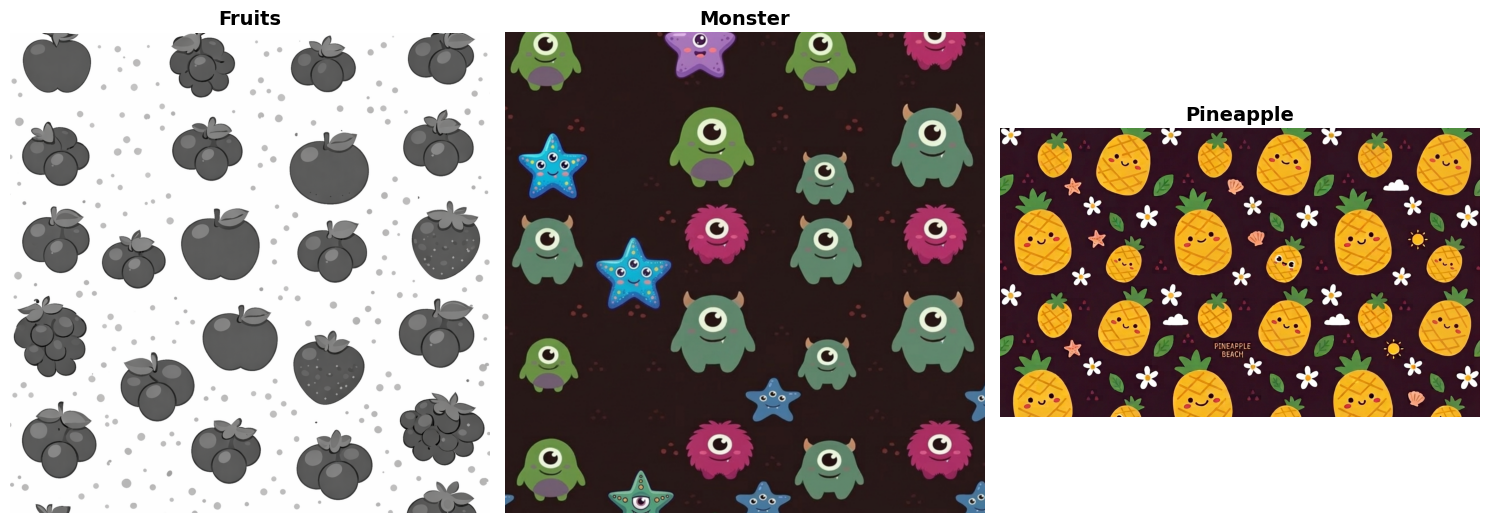

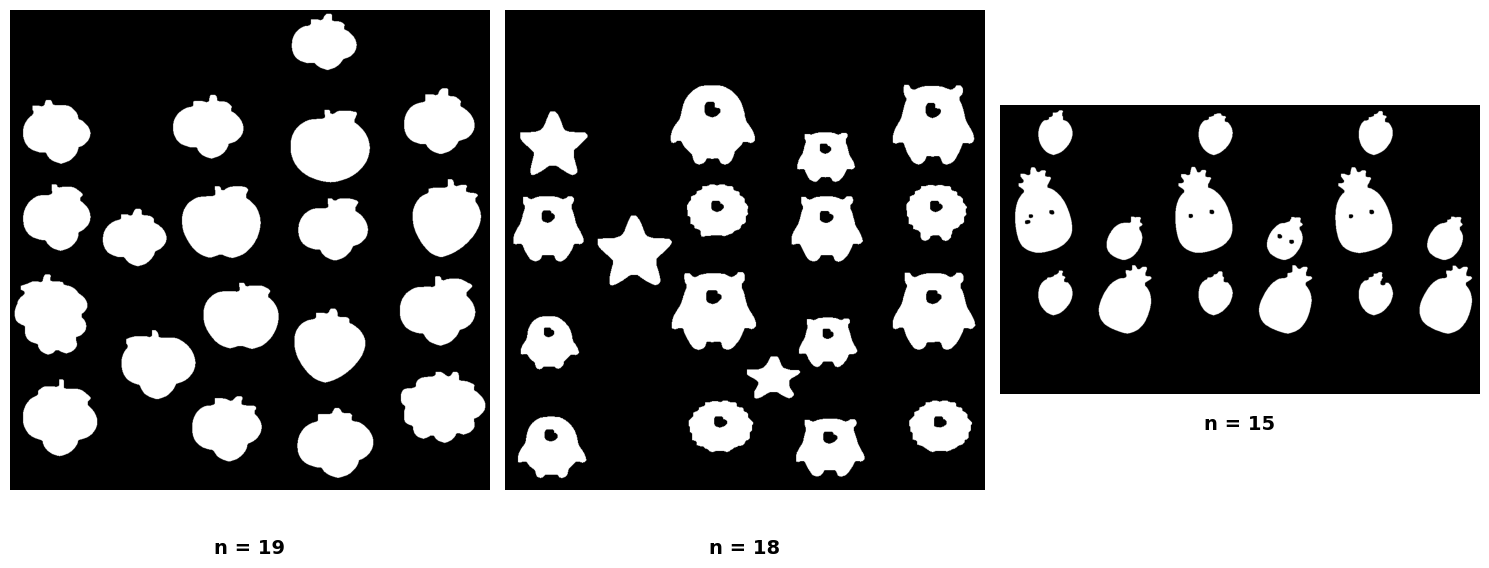

In [212]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
name = ["Fruits", "Monster", "Pineapple"]
i_ = 0
for img in images_rgb:
    axes[i_].imshow(img)
    axes[i_].axis("off")
    axes[i_].set_title(name[i_], fontsize=14, weight='bold')
    i_ = i_ + 1
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 6))

i_ = 0
for img in images_os:

    marker = np.zeros_like(img)
    marker[0, :] = img[0, :]
    marker[-1, :] = img[-1, :]
    marker[:, 0] = np.maximum(marker[:, 0], img[:, 0])
    marker[:, -1] = np.maximum(marker[:, -1], img[:, -1])

    prev = np.zeros_like(marker)
    curr = marker.copy()
    while True:
        dilated = cv.dilate(curr, kernel_open, iterations=1)
        curr = cv.bitwise_and(dilated, img)
        if np.array_equal(curr, prev):
            break
        prev = curr.copy()
    img = cv.subtract(img, curr)

    # Apply the Component analysis function
    analysis = cv.connectedComponentsWithStats(img,8)
    (totalLabels, label_ids, values, centroid) = analysis
    output = np.zeros(img.shape, dtype="uint8")
    # remove small size
    count =0
    for i in range(1, totalLabels) :
        area = values[i, cv.CC_STAT_AREA]
        if area > 2000:
            output[label_ids == i] = 255
            count = count + 1
    axes[i_].imshow(output, cmap='gray')
    axes[i_].set_title(f"n = {count}", y = -0.15, fontsize=14, weight='bold')
    axes[i_].axis("off")
    i_ = i_ +1
plt.tight_layout()
plt.show()

- and then count and print the final number of objects. 